# Procesador de Concentración de Hielo — MWR SAC-D/Aquarius
**Instrumento:** MWR (Microwave Radiometer)  
**Misión:** SAC-D/Aquarius  
**Autores:** Sergio Masuelli · Sebastian Heredia

---

Este notebook recorre el pipeline completo de procesamiento, desde la lectura
del archivo L1B hasta la generación de mapas de Concentración de Hielo (CI),
explicando cada etapa con el código real del proyecto.

---

## Estructura de directorios del proyecto

El proyecto espera la siguiente organización de carpetas bajo la raíz `M5-P4/`.
Las carpetas marcadas con `← crear` deben existir antes de ejecutar;
las marcadas con `← generado` son creadas automáticamente por los scripts.

```
M5-P4/
│
├── Scripts/
│   └── Python/                          ← código fuente del procesador
│       ├── load_l1b.py
│       ├── delta_pg_processor.py
│       ├── multi_passes_pro.py
│       ├── ic_processor.py
│       ├── concat_multipass.py
│       ├── ice_scatter.py
│       ├── grafic_ci.py
│       └── run_l1b_batch.py
│
├── Notebooks/
│   └── MWR_IC_Pipeline.ipynb            ← este notebook
│
└── data/
    │
    ├── L1/                              ← crear  |  archivos L1B de entrada
    │   ├── EO_20130424_000704_CUSS_SACD_MWR_L1B_SCI_078_000_004/
    │   │   └── EO_20130424_000704_CUSS_SACD_MWR_L1B_SCI_078_000_004.h5
    │   ├── EO_20130424_014452_CUSS_SACD_MWR_L1B_SCI_071_000_004/
    │   │   └── EO_20130424_014452_CUSS_SACD_MWR_L1B_SCI_071_000_004.h5
    │   └── ...  (una subcarpeta por pasada)
    │
    ├── landmask/                        ← crear  |  archivo auxiliar
    │   └── landmask_ser.mat             ← máscara de tierra resolución 0.5°
    │
    ├── Temp/
    │   └── DeltaP_G50S1v1/              ← generado por multi_passes_pro mode=1
    │       ├── PGEO_20130424_000704_....mat    (dtemp por pasada)
    │       ├── PGEO_20130424_014452_....mat
    │       ├── ...
    │       ├── MultiPG.mat              ← generado por concat_multipass mode=1
    │       ├── control_EO_20130424_000704_....png  (gráfico ΔT de verificación)
    │       └── Scatter/                 ← generado por ice_scatter
    │           ├── ScatterPG_B1D.mat
    │           ├── ScatterPG_B1D.png
    │           ├── ScatterPG_B1D_log.png
    │           └── ...  (2 escalas × 8 haces × 2 pasos = 32 PNG)
    │
    └── L2/
        └── CI_50S/                      ← generado por multi_passes_pro mode=2
            ├── CIPGEO_20130424_000704_....mat  (CI por pasada)
            ├── CIPGEO_20130424_014452_....mat
            ├── ...
            ├── MultiCI.mat              ← generado por concat_multipass mode=2
            ├── IC_all_TM.png            ← generados por grafic_ci
            ├── IC_wB2_TM.png
            ├── IC_all_NP.png
            ├── IC_wB2_NP.png
            ├── IC_all_SP.png
            └── IC_wB2_SP.png
```

---

## Flujo general de procesamiento

```
data/L1/EO_*/EO_*.h5
         │
         ▼
 1. Lectura HDF5  (load_l1b)
         │
         ▼
 2. Filtro de latitud  +  Flag asc/des
         │
         ▼
 3. Filtro de tierra  (landmask_ser.mat  0.5°)
         │
         ▼
 4. Co-localización de haces  (36.5 GHz ↔ 23.8 GHz)
         │
         ▼
 5. ΔTp = Tb37V − Tb37H
    ΔTg = Tb37H − Tb23H
         │
         ▼  [por pasada]
    data/Temp/DeltaP_G50S1v1/PGEO_*.mat   +   control_*.png
         │
         ├──────────────────────────────────────────────┐
         ▼  [concatenar, axis=2]                        │
    data/Temp/DeltaP_G50S1v1/MultiPG.mat               │
         │                                              │
         ▼                                              ▼
 6. ice_scatter                            7. Concentración de Hielo (CI)
    data/.../Scatter/ScatterPG_B*.png          [por pasada]
                                           data/L2/CI_50S/CIPGEO_*.mat
                                               │
                                               ▼  [concatenar, axis=1]
                                           data/L2/CI_50S/MultiCI.mat
                                               │
                                               ▼
                                        8. grafic_ci
                                           data/L2/CI_50S/IC_*.png
```


## 0. Configuración del entorno

Ajustar `ROOT` a la raíz del proyecto antes de ejecutar el notebook.


In [2]:
import os, sys
import numpy as np
import scipy.io as sio
import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Raíz del proyecto ──────────────────────────────────────────────────
ROOT = os.path.abspath('../../')          # M5-P4/ relativo al notebook
sys.path.insert(0, os.path.join(ROOT, 'Scripts', 'Python'))
os.chdir(ROOT)
print('CWD:', os.getcwd())

# ── Rutas de datos ─────────────────────────────────────────────────────
L1_DIR       = os.path.join(ROOT, 'data', 'L1')
DPG_DIR      = os.path.join(ROOT, 'data', 'Temp', 'DeltaP_G50S1v1')
CI_DIR       = os.path.join(ROOT, 'data', 'L2', 'CI_50S')
LANDMASK     = os.path.join(ROOT, 'data', 'landmask', 'landmask_ser.mat')

# ── Archivo de ejemplo ─────────────────────────────────────────────────
FOLDER   = 'EO_20130424_000704_CUSS_SACD_MWR_L1B_SCI_078_000_004'
H5FILE   = os.path.join(L1_DIR, FOLDER, FOLDER + '.h5')

os.makedirs(DPG_DIR, exist_ok=True)
os.makedirs(CI_DIR,  exist_ok=True)

print('H5FILE existe:', os.path.isfile(H5FILE))
print('LANDMASK existe:', os.path.isfile(LANDMASK))


CWD: /home/adaip/Documentos/cursos/M5/M5-P4-Exc
H5FILE existe: True
LANDMASK existe: True


## 1. Lectura del archivo L1B HDF5

Los datos del MWR se entregan en formato HDF5 con la siguiente estructura de grupos:

```
EO_*.h5
├── Ancillary Data
├── Geolocation Data          ← latitudes y longitudes por canal y bocina
├── Global Metadata
├── MWR Calibrated Radiometric Data  ← temperaturas de brillo (Tb)
└── Quality indicators
```

Cada dataset tiene shape `(N_registros, 8_bocinas)`. La función `load_l1b`
reorganiza esto en un diccionario anidado `data[receiver][f'B{beam}']`
para que el resto del código sea legible.


In [3]:
# Exploramos la estructura del HDF5 antes de cargar
FOLDER = 'EO_20130424_000704_CUSS_SACD_MWR_L1B_SCI_078_000_004'
file = os.path.join(L1_DIR, FOLDER, FOLDER + '.h5')
data = h5py.File(file, 'r')

data.visititems(print)  # Imprime la estructura del archivo HDF5



Ancillary Data <HDF5 group "/Ancillary Data" (12 members)>
Ancillary Data/ascending_flag <HDF5 dataset "ascending_flag": shape (3683,), type "|u1">
Ancillary Data/k_h_geodedic_grid_index <HDF5 dataset "k_h_geodedic_grid_index": shape (3683, 8), type "<i4">
Ancillary Data/k_h_surface_type <HDF5 dataset "k_h_surface_type": shape (3683, 8), type "|i1">
Ancillary Data/ka_h_geodedic_grid_index <HDF5 dataset "ka_h_geodedic_grid_index": shape (3683, 8), type "<i4">
Ancillary Data/ka_h_surface_type <HDF5 dataset "ka_h_surface_type": shape (3683, 8), type "|i1">
Ancillary Data/ka_n45_geodedic_grid_index <HDF5 dataset "ka_n45_geodedic_grid_index": shape (3683, 8), type "<i4">
Ancillary Data/ka_n45_surface_type <HDF5 dataset "ka_n45_surface_type": shape (3683, 8), type "|i1">
Ancillary Data/ka_p45_geodedic_grid_index <HDF5 dataset "ka_p45_geodedic_grid_index": shape (3683, 8), type "<i4">
Ancillary Data/ka_p45_surface_type <HDF5 dataset "ka_p45_surface_type": shape (3683, 8), type "|i1">
Ancillar

### Mapeo de canales

| Receiver | Frecuencia | Pol | Dataset HDF5 |
|---|---|---|---|
| `RX23H` | 23.8 GHz | H | `k_h_antenna_temperature` |
| `RX37H` | 36.5 GHz | H | `ka_h_antenna_temperature` |
| `RX37V` | 36.5 GHz | V | `ka_v_antenna_temperature` |

Para la bocina `j` (1-based): `Tb_bocina_j = ka_h_temperature[:, j-1]`


In [4]:
# Mapeo: receiver → (dataset de temperatura, dataset de lat, dataset de lon)
# Todas las claves son del grupo 'MWR Calibrated Radiometric Data' y
# 'Geolocation Data' respectivamente.
CHANNEL_MAP = {
    'RX23H': {
        'tb_key':  'k_h_antenna_temperature',
        'lat_key': 'k_h_latitude',
        'lon_key': 'k_h_longitude',
    },
    'RX37H': {
        'tb_key':  'ka_h_antenna_temperature',
        'lat_key': 'ka_h_latitude',
        'lon_key': 'ka_h_longitude',
    },
    'RX37V': {
        'tb_key':  'ka_v_antenna_temperature',
        'lat_key': 'ka_v_latitude',
        'lon_key': 'ka_v_longitude',
    },
}

def load_l1b(h5file: str) -> dict:
    """
    Carga el HDF5 y devuelve el dict anidado para delta_pg_processor.

    Parámetros
    ----------
    h5file : str
        Ruta al archivo .h5 del L1B.

    Retorna
    -------
    data : dict
        data[receiver][beam_number] = {'Lat': ndarray, 'Lon': ndarray, 'Tb': ndarray}
        Cada array tiene shape (N,) — un valor por registro temporal.
        beam_number va de 1 a 8 (igual que en el MATLAB original).

    Ejemplo de acceso
    -----------------
        data['RX23H'][1]['Tb']    # Tb 23 GHz H-pol, bocina 1  ← kh_temp[:,0]
        data['RX37H'][3]['Lat']   # lat 36.5 GHz H-pol, bocina 3 ← kah_lat[:,2]
        data['RX37V'][8]['Lon']   # lon 36.5 GHz V-pol, bocina 8 ← kav_lon[:,7]
    """
    NUMBEAM = 8
    data = {}

    with h5py.File(h5file, 'r') as f:
        rad_grp = f['MWR Calibrated Radiometric Data']
        geo_grp = f['Geolocation Data']

        for receiver, keys in CHANNEL_MAP.items():
            # Cargar matrices completas (shape: N_registros × 8 bocinas)
            tb_mat  = rad_grp[keys['tb_key']][:]   # (N, 8)
            lat_mat = geo_grp[keys['lat_key']][:]  # (N, 8)
            lon_mat = geo_grp[keys['lon_key']][:]  # (N, 8)

            data[receiver] = {}

            for beam_num in range(1, NUMBEAM + 1):
                col = beam_num - 1    # índice 0-based de la columna
                data[receiver][f'B{beam_num}'] = {
                    'Tb' : tb_mat [:, col].astype(float),
                    'Lat': lat_mat[:, col].astype(float),
                    'Lon': lon_mat[:, col].astype(float),
                }

    return data

data = load_l1b(H5FILE)

# Verificamos la estructura resultante
print('Receivers disponibles:', list(data.keys()))
print('Bocinas disponibles:', list(data['RX37H'].keys()))
print()
for rx in data:
    N = len(data[rx]['B1']['Tb'])
    tb = data[rx]['B1']['Tb']
    lat = data[rx]['B1']['Lat']
    print(f'{rx}  N={N}  Tb=[{tb.min():.1f}, {tb.max():.1f}] K   '
          f'Lat=[{lat[lat>-100].min():.1f}, {lat[lat>-100].max():.1f}]°')


Receivers disponibles: ['RX23H', 'RX37H', 'RX37V']
Bocinas disponibles: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8']

RX23H  N=3683  Tb=[0.0, 288.6] K   Lat=[-79.2, 84.7]°
RX37H  N=3683  Tb=[0.0, 279.7] K   Lat=[-79.3, 84.6]°
RX37V  N=3683  Tb=[0.0, 292.8] K   Lat=[-79.2, 84.7]°


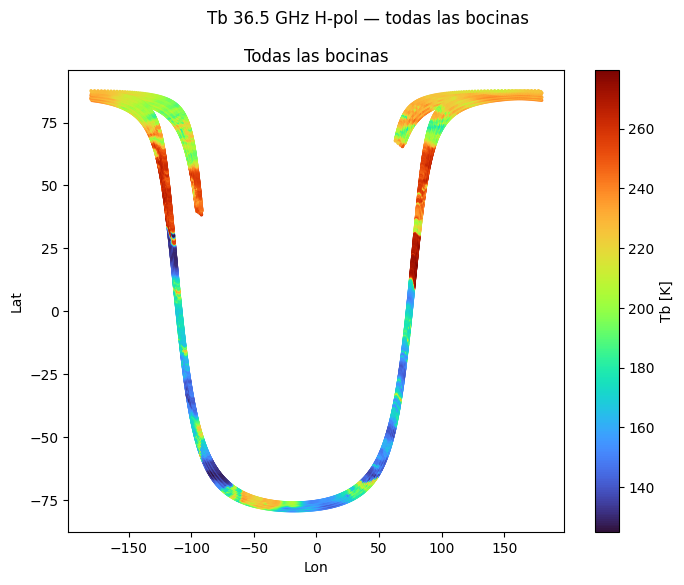

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Tb 36.5 GHz H-pol — todas las bocinas', fontsize=12)

# Concatenar todo
tb_all  = np.concatenate([data['RX37H'][f'B{j+1}']['Tb']  for j in range(8)])
lat_all = np.concatenate([data['RX37H'][f'B{j+1}']['Lat'] for j in range(8)])
lon_all = np.concatenate([data['RX37H'][f'B{j+1}']['Lon'] for j in range(8)])

# Filtrado
valid = tb_all > 0

# Escala de color robusta
# vmin, vmax = np.percentile(tb_all[valid], [2, 98])

# Scatter único
sc = ax.scatter(lon_all[valid], lat_all[valid],
                c=tb_all[valid],s=2,
                cmap='turbo')

ax.set_title('Todas las bocinas')
ax.set_xlabel('Lon')
ax.set_ylabel('Lat')

fig.colorbar(sc, ax=ax, label='Tb [K]')

plt.show()

## 2. Detección del flag ascendente / descendente

Cada pasada del satélite tiene una parte **descendente** (de norte a sur)
y una **ascendente** (de sur a norte). Para asignar el flag se detectan
los índices del mínimo (`isouth`) y máximo (`inorth`) de latitud en el haz 1.

La máscara `lat > -100` excluye los valores de relleno (-999) sin alterar
los valores válidos.

```
Índice k:   0 ─────────── isouth ─────────── inorth ─────────── N
Flag:           1 (des)       0        2 (asc)      0      1 (des)
```


isouth = 1957  →  lat = -79.26°
inorth = 429  →  lat = 84.65°


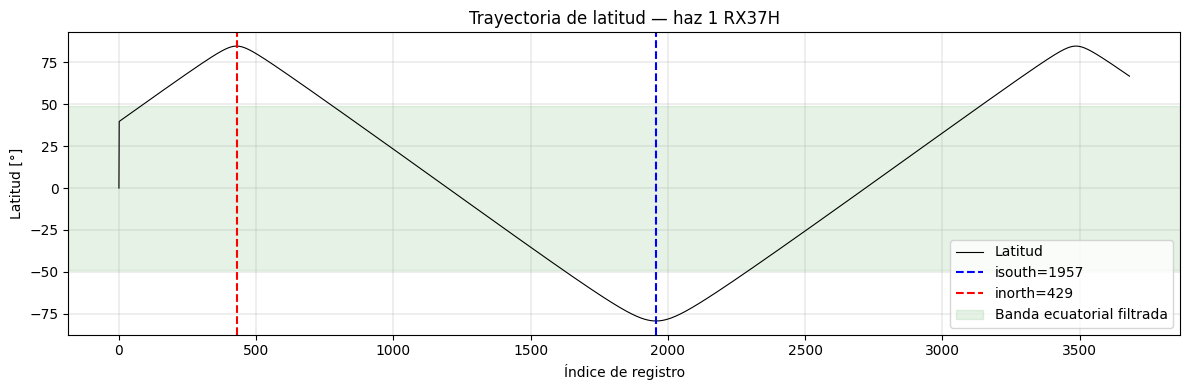

In [6]:
lat_b1 = data['RX37H']['B1']['Lat']
auxx   = np.where(lat_b1 > -100.0, lat_b1, 0.0)
inorth = int(np.argmax(auxx))
isouth = int(np.argmin(auxx))

print(f'isouth = {isouth}  →  lat = {lat_b1[isouth]:.2f}°')
print(f'inorth = {inorth}  →  lat = {lat_b1[inorth]:.2f}°')

# Visualizamos la trayectoria de latitud con el flag
fig, ax = plt.subplots(figsize=(12, 4))
idx_valid = lat_b1 > -100
idx = np.arange(len(lat_b1))
ax.plot(idx[idx_valid], lat_b1[idx_valid], 'k-', lw=0.8, label='Latitud')
ax.axvline(isouth, color='blue',  linestyle='--', label=f'isouth={isouth}')
ax.axvline(inorth, color='red',   linestyle='--', label=f'inorth={inorth}')
ax.axhspan(-49, 49, alpha=0.1, color='green', label='Banda ecuatorial filtrada')
ax.set_xlabel('Índice de registro')
ax.set_ylabel('Latitud [°]')
ax.set_title('Trayectoria de latitud — haz 1 RX37H')
ax.legend()
ax.grid(True, linewidth=0.3)
plt.tight_layout()
plt.show()


## 3. Filtro de latitud

El algoritmo de CI solo es válido fuera de la banda ecuatorial.
Se conservan únicamente los registros con:

$$|\text{lat}| > 49° \quad \text{y} \quad |\text{lat}| < 90°$$

El filtro usa la latitud del **haz 1** como referencia para todos los
haces simultáneamente, ya que los 8 haces son muestreados en el mismo
instante temporal.

La salida `rawlat` tiene shape `(3_bandas, 8_haces, 4_vars, N_max)`,
donde las 4 variables son: lat, lon, Tb, flag.


Registros por banda después del filtro lat:
  RX37H: 1916 registros  (de 3683 totales  →  52.0% conservado)
  RX37V: 1917 registros  (de 3683 totales  →  52.0% conservado)
  RX23H: 1817 registros  (de 3683 totales  →  49.3% conservado)


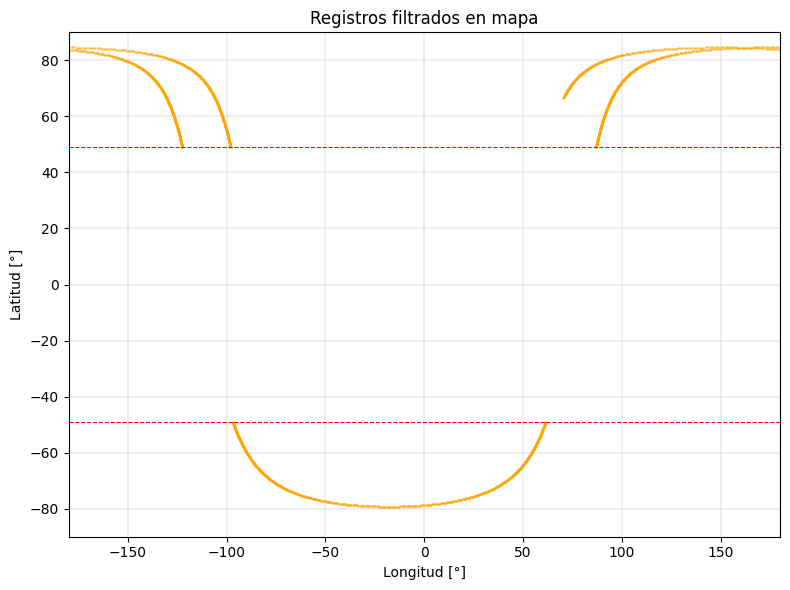

In [10]:
# ===========================================================================
# 2.  FILTRO DE LATITUD
# ===========================================================================
def _asc_des_flag(k: int, isouth: int, inorth: int) -> int:
    """
    Asigna el flag para el índice k (0-based).

    Asume que el paso comienza descendente (igual que el comentario MATLAB).
        k < isouth          →  1  (descendente)
        k == isouth         →  0  (turning point sur)
        isouth < k < inorth →  2  (ascendente)
        k == inorth         →  0  (turning point norte)
        k > inorth          →  1  (descendente de nuevo)
    """
    if   k <  isouth: return 1
    elif k == isouth: return 0
    elif k <  inorth: return 2
    elif k == inorth: return 0
    else:             return 1

def _find_turning_points(data: dict) -> tuple[int, int]:
    """
    Detecta isouth e inorth (índices 0-based) como el MATLAB:

        auxx = (data.RX37H.B1.Lat > -100) .* data.RX37H.B1.Lat
        [~, inorth] = max(auxx)
        [~, isouth] = min(auxx)

    La máscara > -100 excluye fill values sin alterar los valores válidos.
    """
    lat    = data['RX37H']['B1']['Lat']
    auxx   = np.where(lat > -100.0, lat, 0.0)
    inorth = int(np.argmax(auxx))
    isouth = int(np.argmin(auxx))
    return isouth, inorth

def apply_lat_filter(data: dict) -> tuple[np.ndarray, np.ndarray, list[int]]:
    """
    Conserva solo los registros con latitud de referencia (haz 1)
    fuera de la banda ecuatorial: |lat| > 49° y |lat| < 90°.

    Para cada registro válido copia lat, lon, Tb y flag a rawlat,
    y guarda el índice original en indlat.

    Dimensiones (0-based en Python):
        rawlat  (NUMBAND, NUMBEAM, NUMVAR, numrec)
        indlat  (NUMBAND, NUMBEAM, numrec)
        counlat [3]  — número de registros válidos por banda
    """
    isouth, inorth = _find_turning_points(data)
    numrec  = len(data['RX37H']['B1']['Tb'])

    rawlat  = FILL * np.ones((NUMBAND, NUMBEAM, NUMVAR, numrec))
    indlat  = FILL * np.ones((NUMBAND, NUMBEAM, numrec))
    counlat = [0, 0, 0]

    for i, rx in enumerate(RECEIVERS):
        auxlat = data[rx]['B1']['Lat']    # haz 1 como referencia de filtro
        c = 0
        for k in range(numrec):
            lat_k = auxlat[k]
            if (lat_k > N_LAT or lat_k < S_LAT) and abs(lat_k) < 90.0:
                flag = _asc_des_flag(k, isouth, inorth)
                for ji in range(NUMBEAM):
                    bkey = f'B{ji + 1}'
                    rawlat[i, ji, 0, c] = data[rx][bkey]['Lat'][k]
                    rawlat[i, ji, 1, c] = data[rx][bkey]['Lon'][k]
                    rawlat[i, ji, 2, c] = data[rx][bkey]['Tb'][k]
                    rawlat[i, ji, 3, c] = flag
                    indlat[i, ji, c]    = k
                c += 1
        counlat[i] = c

    return rawlat, indlat, counlat

# ---------------------------------------------------------------------------
# Constantes globales
# ---------------------------------------------------------------------------
FILL      = -999.0
NUMBAND   =  3
NUMBEAM   =  8
NUMVAR    =  4      # variables del dato crudo: lat, lon, Tb, asc_des
RECEIVERS = ['RX37H', 'RX37V', 'RX23H']

N_LAT       =  49.0          # límite norte del filtro de latitud
S_LAT       = -49.0          # límite sur


rawlat, indlat, counlat = apply_lat_filter(data)

print('Registros por banda después del filtro lat:')
for i, rx in enumerate(['RX37H', 'RX37V', 'RX23H']):
    print(f'  {rx}: {counlat[i]} registros  '
          f'(de {len(data[rx]["B1"]["Tb"])} totales  →  '
          f'{counlat[i]/len(data[rx]["B1"]["Tb"])*100:.1f}% conservado)')

# Verificamos la distribución geográfica
lats_filtradas = rawlat[0, 0, 0, :counlat[0]]  # RX37H, bocina 1, lat
lons_filtradas = rawlat[0, 0, 1, :counlat[0]]
fig, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(lons_filtradas, lats_filtradas, s=1, c='orange', alpha=0.5)
ax2.set_xlabel('Longitud [°]');  ax2.set_ylabel('Latitud [°]')
ax2.set_title('Registros filtrados en mapa')
ax2.axhline(49, color='red', linestyle='--', lw=0.8)
ax2.axhline(-49, color='red', linestyle='--', lw=0.8)
ax2.set_xlim(-180, 180);  ax2.set_ylim(-90, 90)
ax2.grid(True, linewidth=0.3)
plt.tight_layout();  plt.show()


## 4. Filtro de tierra (land mask)

El MWR observa tanto océano como tierra. Para el cálculo de CI solo
son relevantes los píxeles sobre **océano o hielo marino**.

Se usa una máscara de tierra de resolución **0.5°** (`landmask_ser.mat`).
La conversión lat/lon → índice de la máscara es:

```python
alat = round((lat + 90)  * 2)   # [0, 360]
alon = round((lon + 180) * 2) % 720  # [0, 719]
```

El archivo se carga con `flipud` para que el eje de latitud quede
orientado de sur a norte (idéntico al MATLAB original).

Las bandas 36.5 GHz H y V comparten la misma posición espacial,
por lo que se filtran juntas usando H como referencia.


Land mask shape: (360, 720)  (filas=lat, cols=lon, 0.5°/px)
Valores únicos: [0 1]  (0=océano, 1=tierra)


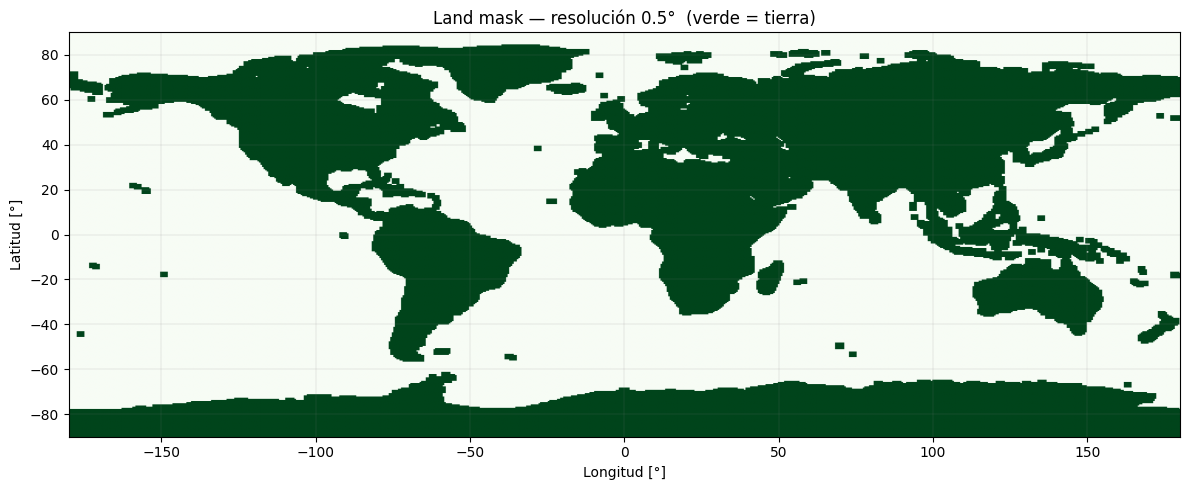

In [11]:
# from delta_pg_processor import load_landmask, apply_land_filter


# Cargar máscara de tierra
LANDMASK     = os.path.join(ROOT, 'data', 'landmask', 'landmask_ser.mat')
mat = sio.loadmat(LANDMASK)
landmask = np.flipud(mat['landmask_ser'].astype(np.int8))

print(f'Land mask shape: {landmask.shape}  (filas=lat, cols=lon, 0.5°/px)')
print(f'Valores únicos: {np.unique(landmask)}  (0=océano, 1=tierra)')

# Visualizamos la máscara
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(landmask, aspect='auto', cmap='Greens',
          extent=[-180, 180, -90, 90], origin='lower')
ax.set_title('Land mask — resolución 0.5°  (verde = tierra)')
ax.set_xlabel('Longitud [°]');  ax.set_ylabel('Latitud [°]')
ax.grid(True, linewidth=0.3, color='gray', alpha=0.4)
plt.tight_layout();  plt.show()



# landmask = load_landmask(LANDMASK)




Registros por banda/haz después del filtro de tierra:
  36.5 GHz (H+V): [820 825 860 897 893 911 927 924]  (haces 1-8)
  23.8 GHz  (H):  [793 792 832 846 856 862 889 881]  (haces 1-8)


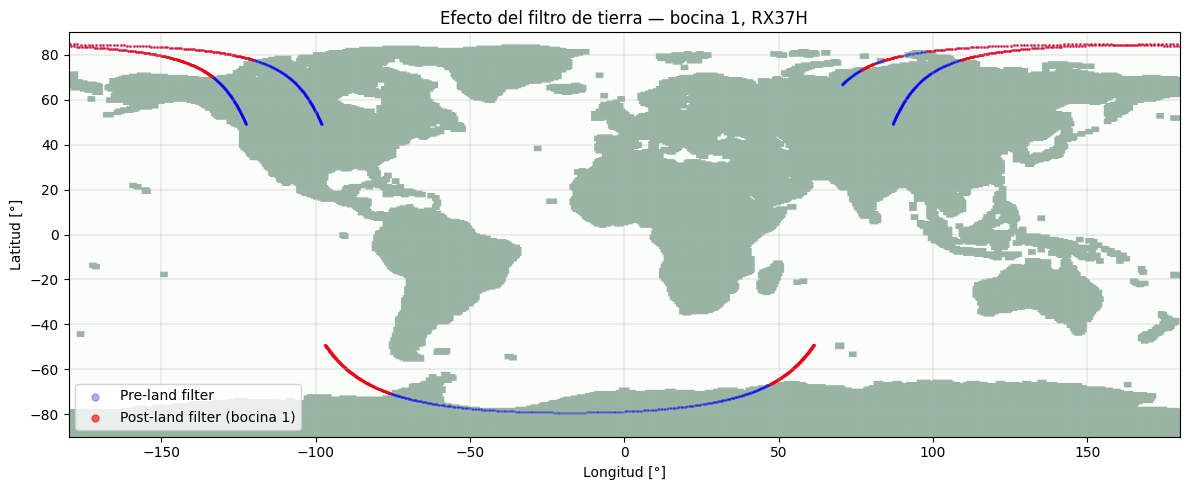

In [12]:

MASK_LAT    = 361            # filas del land mask (180° / 0.5° + 1)
MASK_LON    = 720            # columnas del land mask (360° / 0.5°)


def apply_land_filter(rawlat: np.ndarray, indlat: np.ndarray,
                      counlat: list[int],
                      landmask: np.ndarray
                      ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
       Elimina los registros cuya posición cae sobre tierra.

       La banda 36.5 GHz H (band 0) se usa como referencia de posición para
       filtrar simultáneamente H y V (bands 0 y 1) — mismo píxel espacial.
       La banda 23.8 GHz (band 2) se filtra independientemente.

       Parámetros
       ----------
       rawlat   : ndarray (NUMBAND, NUMBEAM, NUMVAR, N)
                  Datos filtrados por latitud. NUMVAR = [lat, lon, Tb, flag].
       indlat   : ndarray (NUMBAND, NUMBEAM, N)
                  Índice original en el L1B de cada registro filtrado.
       counlat  : list[int], longitud 3
                  Número de registros válidos por banda tras el filtro de latitud:
                    counlat[0] → RX37H  (36.5 GHz H-pol)
                    counlat[1] → RX37V  (36.5 GHz V-pol)
                    counlat[2] → RX23H  (23.8 GHz H-pol)
                  Define cuántos elementos de rawlat/indlat son válidos por banda.
       landmask : ndarray (MASK_LAT, MASK_LON), int8
                  Máscara de tierra a 0.5° de resolución (0=océano, 1=tierra),
                  cargada con flipud para orientación sur→norte.

       Retorna
       -------
       rawland  : ndarray (NUMBAND, NUMBEAM, NUMVAR, max_count)
                  Registros oceánicos por banda y haz.
       indland  : ndarray (NUMBAND-1, NUMBEAM, max_count)
                  Índices originales en el L1B. NUMBAND-1 porque RX37H y RX37V
                  comparten posición espacial y se indexan juntos.
       counland : ndarray (NUMBAND-1, NUMBEAM), int
                  Número de registros oceánicos válidos por banda y haz:
                    counland[0, j] → RX37H+RX37V, haz j
                    counland[1, j] → RX23H,        haz j
   """
    max_count = max(max(counlat), 1)
    rawland   = FILL * np.ones((NUMBAND,     NUMBEAM, NUMVAR, max_count))
    indland   = FILL * np.ones((NUMBAND - 1, NUMBEAM, max_count))
    counland  = np.zeros((NUMBAND - 1, NUMBEAM), dtype=int)

    # --- 36.5 GHz H+V  (band index 0 como referencia de posición) ---
    for ji in range(NUMBEAM):
        c = 0
        for k in range(counlat[0]):
            lat = rawlat[0, ji, 0, k]
            lon = rawlat[0, ji, 1, k]
            if abs(lat) >= 90.0:
                continue
            alat, alon = _latlon_to_mask_idx(lat, lon)
            if landmask[alat, alon] == 0:          # 0 = océano
                rawland[0, ji, :, c] = rawlat[0, ji, :, k]   # RX37H
                rawland[1, ji, :, c] = rawlat[1, ji, :, k]   # RX37V
                indland[0, ji, c]    = indlat[0, ji, k]
                c += 1
        counland[0, ji] = c

    # --- 23.8 GHz  (band index 2) ---
    for ji in range(NUMBEAM):
        c = 0
        for k in range(counlat[2]):
            lat = rawlat[2, ji, 0, k]
            lon = rawlat[2, ji, 1, k]
            if abs(lat) >= 90.0:
                continue
            alat, alon = _latlon_to_mask_idx(lat, lon)
            if landmask[alat, alon] == 0:
                rawland[2, ji, :, c] = rawlat[2, ji, :, k]
                indland[1, ji, c]    = indlat[2, ji, k]
                c += 1
        counland[1, ji] = c

    return rawland, indland, counland

def _latlon_to_mask_idx(lat: float, lon: float) -> tuple[int, int]:
    """
    Convierte lat/lon a índices 0-based del land mask de 0.5°.

    MATLAB (1-based):
        alat = round((lat+90)*2) + 1
        alon = round((lon+180)*2) + 1
        if alon > MASK_LON: alon = alon - MASK_LON + 1

    Python (0-based):
        alat = round((lat+90)*2)              rango [0, 360]
        alon = round((lon+180)*2) % MASK_LON  rango [0, 719]
    """
    alat = int(round((lat  +  90.0) * 2))
    alon = int(round((lon  + 180.0) * 2)) % MASK_LON
    return alat, alon


rawland, indland, counland = apply_land_filter(rawlat, indlat, counlat, landmask)

print('Registros por banda/haz después del filtro de tierra:')
print(f'  36.5 GHz (H+V): {counland[0]}  (haces 1-8)')
print(f'  23.8 GHz  (H):  {counland[1]}  (haces 1-8)')

# Comparamos antes y después del filtro de tierra
lat_postland = rawland[0, 0, 0, :counland[0, 0]]
lon_postland = rawland[0, 0, 1, :counland[0, 0]]

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(landmask, aspect='auto', cmap='Greens',
          extent=[-180, 180, -90, 90], origin='lower', alpha=0.4)
ax.scatter(lons_filtradas, lats_filtradas, s=1, c='blue', alpha=0.3, label='Pre-land filter')
ax.scatter(lon_postland, lat_postland, s=1, c='red',  alpha=0.6, label='Post-land filter (bocina 1)')
ax.set_xlim(-180, 180);  ax.set_ylim(-90, 90)
ax.set_xlabel('Longitud [°]');  ax.set_ylabel('Latitud [°]')
ax.set_title('Efecto del filtro de tierra — bocina 1, RX37H')
ax.legend(markerscale=5);  ax.grid(True, linewidth=0.3)
plt.tight_layout();  plt.show()


## 5. Co-localización de haces

Para calcular ΔTg = Tb37H − Tb23H es necesario que ambas bandas
correspondan al **mismo punto geográfico**. Las frecuencias 36.5 y 23.8 GHz
tienen distinta resolución espacial y distintos patrones de muestreo.

### Etapa A — Promedio ponderado de tripletes (36.5 GHz H+V)
Los 3 registros consecutivos del mismo haz se combinan con el punto
central pesando doble:

$$T_b^{coloc} = \frac{T_b[k-1] + 2 \cdot T_b[k] + T_b[k+1]}{4}$$

Se verifica que los índices originales sean consecutivos (`ind[k+2] - ind[k] == 2`).

### Etapa B — Vecino más cercano (23.8 GHz)
Para cada punto co-localizado de 36 GHz se avanza un puntero secuencial
sobre los registros 23 GHz hasta encontrar el mínimo de distancia
(distancia de gran círculo en grados). El puntero **no se resetea**
entre iteraciones — lo mismo que en el MATLAB original.

### Etapa C — Filtro de vecindad
Se descartan los pares (37, 23 GHz) cuya separación supera **25/108° ≈ 13 km**.


In [13]:
DIST_THRESH = 25.0 / 108.0  # umbral de vecindad inter-banda en grados
# -----------------------------------------
def collocate_beams(rawland: np.ndarray, indland: np.ndarray,
                    counland: np.ndarray
                    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Co-localización de los tres receivers en un punto común.

    Etapa A — 36.5 GHz H+V (pivot):
        Agrupa registros en tripletes con test de contigüidad
        (índice original consecutivo: ind[k+2] - ind[k] == 2).
        Tb co-localizado = (Tb[k] + 2·Tb[k+1] + Tb[k+2]) / 4

    Etapa B — 23.8 GHz (búsqueda secuencial):
        Para cada punto co-localizado de 36 GHz avanza un puntero
        compartido sobre el array 23H hasta encontrar el mínimo local
        (dist1 > dist2) y aplica el mismo promedio de tripletes.
        El puntero NO se resetea entre iteraciones de k (igual MATLAB).

    Etapa C — Filtro de vecindad:
        Descarta pares (37,23) con distancia > DIST_THRESH grados.
        rawloc se compacta in-place; counloc[1,j] guarda el conteo final.

    Retorna
    -------
    rawloc   (NUMBAND, NUMBEAM, NUMVAR, M)
    indloc   (NUMBAND-1, NUMBEAM, M)
    counloc  (NUMBAND-1, NUMBEAM)  int
        counloc[0,j] = puntos co-localizados 36 GHz
        counloc[1,j] = puntos válidos tras el filtro de vecindad
    """
    max_coloc = max(1, int(np.max(counland)) // 3)
    rawloc    = FILL * np.ones((NUMBAND,     NUMBEAM, NUMVAR, max_coloc))
    indloc    = FILL * np.ones((NUMBAND - 1, NUMBEAM, max_coloc))
    counloc   = np.zeros((NUMBAND - 1, NUMBEAM), dtype=int)

    # ---- Etapa A: 36.5 GHz H+V -----------------------------------------
    for ji in range(NUMBEAM):
        n36   = counland[0, ji]
        n_tri = n36 // 3
        cnt   = 0
        for k in range(n_tri):
            i0, i1, i2 = 3 * k, 3 * k + 1, 3 * k + 2
            # Test contigüidad: diferencia de índices originales debe ser 2
            if indland[0, ji, i2] - indland[0, ji, i0] == 2:
                # lat/lon del punto central
                rawloc[0:2, ji, 0:2, cnt] = rawland[0:2, ji, 0:2, i1]
                # Tb ponderado: Tb0 + 2·Tb1 + Tb2  (se divide por 4 al final)
                rawloc[0:2, ji, 2, cnt] = (rawland[0:2, ji, 2, i0]
                                           + rawland[0:2, ji, 2, i2]
                                           + 2.0 * rawland[0:2, ji, 2, i1])
                # flag asc/des del punto central
                rawloc[0:2, ji, 3, cnt] = rawland[0:2, ji, 3, i1]
                indloc[0, ji, cnt]       = indland[0, ji, i1]
                cnt += 1

        if cnt > 0:
            rawloc[0:2, ji, 2, 0:cnt] /= 4.0   # normalizar Tb
        counloc[0, ji] = cnt

    # ---- Etapa B: 23.8 GHz (búsqueda secuencial) -----------------------
    # ptr23[ji] es el puntero corriente sobre rawland[2,ji,...]
    # NO se resetea entre iteraciones de k, igual que counloc(2,j) en MATLAB
    ptr23 = np.zeros(NUMBEAM, dtype=int)

    for ji in range(NUMBEAM):
        n23       = counland[1, ji]
        n36_coloc = counloc[0, ji]

        for k in range(n36_coloc):
            ref_lat = rawloc[0, ji, 0, k]
            ref_lon = rawloc[0, ji, 1, k]

            dist1 = 1001.0
            dist2 = 1000.0

            # Avanzar puntero mientras la distancia siga decreciendo
            while dist1 > dist2 and ptr23[ji] < n23 - 1:
                ptr23[ji] += 1
                dist1 = dist2
                dist2 = _great_circle_deg(
                    ref_lat, ref_lon,
                    rawland[2, ji, 0, ptr23[ji]],
                    rawland[2, ji, 1, ptr23[ji]],
                )

            # ptr23[ji] > 1  (0-based)  ≡  counloc(2,j) > 2  (1-based MATLAB)
            if ptr23[ji] > 1:
                ptr23[ji] -= 1      # retroceder al mínimo local
                c = ptr23[ji]

                # Test de contigüidad del triplete 23 GHz
                if (c + 1 < n23 and c - 1 >= 0
                        and indland[1, ji, c + 1] - indland[1, ji, c - 1] == 2):
                    rawloc[2, ji, 0:2, k] = rawland[2, ji, 0:2, c]
                    rawloc[2, ji, 2,   k] = (rawland[2, ji, 2, c - 1]
                                             + rawland[2, ji, 2, c + 1]
                                             + 2.0 * rawland[2, ji, 2, c])
                    rawloc[2, ji, 3, k]   = rawland[2, ji, 3, c]
                    # Nota: el MATLAB original usa indland(1,j,...) aquí
                    # (band 0, no 1) — posible bug replicado fielmente
                    indloc[1, ji, k] = indland[0, ji, c]

    rawloc[2, :, 2, :] /= 4.0   # normalizar Tb de 23 GHz

    # ---- Etapa C: filtro de vecindad -----------------------------------
    # counloc[1,ji] se reutiliza como puntero de escritura (compactación)
    for ji in range(NUMBEAM):
        write_ptr = 0
        for k in range(counloc[0, ji]):
            lat_37 = rawloc[0, ji, 0, k]
            lon_37 = rawloc[0, ji, 1, k]
            lat_23 = rawloc[2, ji, 0, k]
            lon_23 = rawloc[2, ji, 1, k]

            if lat_37 == FILL or lat_23 == FILL:
                continue

            dist = _great_circle_deg(lat_37, lon_37, lat_23, lon_23)
            if dist < DIST_THRESH:
                rawloc[:, ji, :, write_ptr] = rawloc[:, ji, :, k]
                indloc[:, ji, write_ptr]    = indloc[:, ji, k]
                write_ptr += 1

        counloc[1, ji] = write_ptr

    return rawloc, indloc, counloc

# ===========================================================================
# 4.  CO-LOCALIZACIÓN DE HACES
# ===========================================================================

def _great_circle_deg(lat1: float, lon1: float,
                      lat2: float, lon2: float) -> float:
    """
    Distancia de gran círculo en GRADOS — equivalente a la función
    ``distance()`` de la Mapping Toolbox de MATLAB (modo 'gc').
    """
    r = np.radians
    a = (np.sin((r(lat2) - r(lat1)) / 2) ** 2
         + np.cos(r(lat1)) * np.cos(r(lat2))
         * np.sin((r(lon2) - r(lon1)) / 2) ** 2)
    return float(np.degrees(2.0 * np.arcsin(np.clip(np.sqrt(a), 0.0, 1.0))))
# -----------------------------------------------

rawloc, indloc, counloc = collocate_beams(rawland, indland, counland)

print('Co-localización 36 GHz (tripletes):')
print(f'  {counloc[0]}  puntos por haz')
print()
print('Válidos tras filtro de vecindad (distancia < 25/108°):')
print(f'  {counloc[1]}  puntos por haz')

# # Verificamos que las coordenadas de 37 y 23 GHz están cerca
# from delta_pg_processor import _great_circle_deg
dists = []
ji = 0  # bocina 1
n = counloc[1, ji]
for k in range(min(n, 200)):
    lat37 = rawloc[0, ji, 0, k];  lon37 = rawloc[0, ji, 1, k]
    lat23 = rawloc[2, ji, 0, k];  lon23 = rawloc[2, ji, 1, k]
    if lat37 != -999 and lat23 != -999:
        dists.append(_great_circle_deg(lat37, lon37, lat23, lon23))

print(f'\nDistancia media 37↔23 GHz (bocina 1, primeros 200 pts): {np.mean(dists):.4f}°  ({np.mean(dists)*111:.2f} km)')
print(f'Umbral de corte: {25/108:.4f}°  ({25/108*111:.2f} km)')


Co-localización 36 GHz (tripletes):
  [269 270 280 294 294 298 303 302]  puntos por haz

Válidos tras filtro de vecindad (distancia < 25/108°):
  [260 245 266 272 274 280 274 287]  puntos por haz

Distancia media 37↔23 GHz (bocina 1, primeros 200 pts): 0.0425°  (4.71 km)
Umbral de corte: 0.2315°  (25.69 km)


## 6. Cálculo de ΔTp y ΔTg

Con los haces co-localizados se calculan las dos diferencias de temperatura:

| Variable | Definición | Interpretación |
|---|---|---|
| **ΔTp** | $T_b^{37V} - T_b^{37H}$ | Diferencia de polarización — sensible a rugosidad superficial |
| **ΔTg** | $T_b^{37H} - T_b^{23H}$ | Diferencia de gradiente espectral — sensible a tipo de superficie |

El hielo marino tiene ΔTp pequeño y ΔTg negativo o cercano a cero.
El océano abierto tiene ΔTp grande y ΔTg positivo.
Esta separación en el espacio (ΔTp, ΔTg) es la base del algoritmo de CI.
Completar la compute_dtemp


In [14]:
# ===========================================================================
# 5.  CÁLCULO DE ΔTp y ΔTg
# ===========================================================================

def compute_dtemp(rawloc: np.ndarray,
                  counloc: np.ndarray) -> np.ndarray:
    """
    Calcula las diferencias de temperatura de brillo por haz y arma la
    variable de salida dtemp.

        ΔTp = Tb37V − Tb37H   (diferencia de polarización)
        ΔTg = Tb37H − Tb23H   (diferencia de gradiente espectral)

    Parámetros
    ----------
    rawloc : ndarray (NUMBAND=3, NUMBEAM=8, NUMVAR=4, M)
        Datos co-localizados entre las tres bandas, salida de collocate_beams().
        Cada punto tiene las tres bandas alineadas al mismo píxel geográfico.

        Eje 0 — banda:
            0 → RX37H (36.5 GHz H-pol) — pivote de posición y flag
            1 → RX37V (36.5 GHz V-pol)
            2 → RX23H (23.8 GHz H-pol)
        Eje 1 — haz: 0..7  (bocinas B1..B8)
        Eje 2 — variable:
            0 → lat
            1 → lon
            2 → Tb  (promedio ponderado del triplete: (Tb0 + 2·Tb1 + Tb2) / 4)
            3 → flag asc/des
        Eje 3 — registro: 0..M-1

    counloc : ndarray (2, NUMBEAM=8), int
        Contadores de puntos válidos por haz, salida de collocate_beams().
        Representa dos etapas sucesivas del proceso de co-localización:
            counloc[0, j] → puntos tras el promedio de tripletes 36 GHz
            counloc[1, j] → puntos tras el filtro de vecindad 37↔23 GHz
                            (distancia < 25/108° ≈ 13 km)
        Se usa counloc[1, j] porque es el conteo final: solo esos puntos
        tienen las tres bandas correctamente co-localizadas.

    Retorna
    -------
    dtemp : ndarray (NUMBEAM=8, 5, M)
        M = max(counloc[1, :])  — máximo de registros válidos entre todos los haces.
        Las posiciones sin datos quedan rellenas con FILL = -999.

        Eje 1 — variable:
            0 → lat
            1 → lon
            2 → ΔTp = Tb37V − Tb37H  [K]
            3 → ΔTg = Tb37H − Tb23H  [K]
            4 → flag asc/des  (2=ascendente, 1=descendente, 0=turning point)
    """
    M = int(np.max(counloc[1, :]))
    if M == 0:
        M = 1
    dtemp = FILL * np.ones((NUMBEAM, NUMVAR + 1, M))

    for ji in range(NUMBEAM):
        n = counloc[1, ji]
        if n == 0:
            continue
        dtemp[ji, 0, :n] = rawloc[0, ji, 0, :n]                          # lat
        dtemp[ji, 1, :n] = rawloc[0, ji, 1, :n]                          # lon
        dtemp[ji, 2, :n] = rawloc[1, ji, 2, :n] - rawloc[0, ji, 2, :n]  # ΔTp
        dtemp[ji, 3, :n] = rawloc[0, ji, 2, :n] - rawloc[2, ji, 2, :n]  # ΔTg
        dtemp[ji, 4, :n] = rawloc[0, ji, 3, :n]                          # flag

    return dtemp
# -------------------------------------------------------------------
dtemp = compute_dtemp(rawloc, counloc)
print(f'dtemp shape: {dtemp.shape}  → (8_haces, 5_vars, N_registros)')
print('Variables: [lat, lon, ΔTp, ΔTg, flag_asc_des]')

# Estadísticas por haz
print('\nEstadísticas de ΔTp y ΔTg por haz (registros válidos):')
print(f'{"Haz":>5}  {"N":>6}  {"ΔTp_mean":>10}  {"ΔTp_std":>8}  {"ΔTg_mean":>10}  {"ΔTg_std":>8}')
for ji in range(8):
    n = counloc[1, ji]
    if n == 0: continue
    dtp = dtemp[ji, 2, :n]
    dtg = dtemp[ji, 3, :n]
    valid = (dtp != -999) & (dtg != -999)
    print(f'{ji+1:>5}  {valid.sum():>6}  {dtp[valid].mean():>10.2f}  {dtp[valid].std():>8.2f}  {dtg[valid].mean():>10.2f}  {dtg[valid].std():>8.2f}')


dtemp shape: (8, 5, 287)  → (8_haces, 5_vars, N_registros)
Variables: [lat, lon, ΔTp, ΔTg, flag_asc_des]

Estadísticas de ΔTp y ΔTg por haz (registros válidos):
  Haz       N    ΔTp_mean   ΔTp_std    ΔTg_mean   ΔTg_std
    1     260       35.86     19.42       -0.69     13.11
    2     245       45.67     23.55       -4.25     13.05
    3     266       34.80     19.24       -1.98     13.39
    4     272       45.45     23.45       -5.03     12.54
    5     274       34.62     18.83       -1.45     12.65
    6     280       45.21     23.63       -3.25     12.73
    7     274       38.06     18.02       -3.56     12.42
    8     287       46.00     23.49       -4.33     12.34


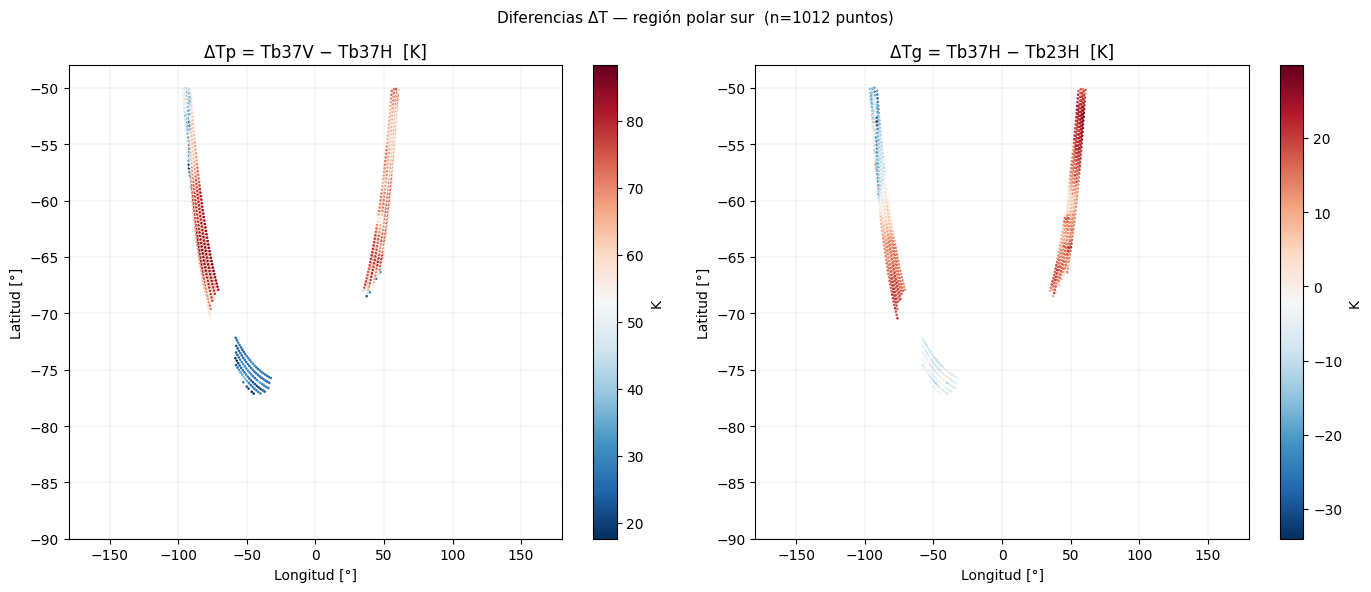

In [15]:
# Gráfico de control: ΔTp y ΔTg en mapa polar sur
FILL = -999.0
lats, lons, dtps, dtgs = [], [], [], []
for ji in range(dtemp.shape[0]):
    for k in range(dtemp.shape[2]):
        lat, lon = dtemp[ji,0,k], dtemp[ji,1,k]
        dtp, dtg = dtemp[ji,2,k], dtemp[ji,3,k]
        if any(v == FILL for v in [lat,lon,dtp,dtg]): continue
        if lat > -50: continue   # solo Antártida
        lats.append(lat); lons.append(lon)
        dtps.append(dtp); dtgs.append(dtg)

lats=np.array(lats); lons=np.array(lons)
dtps=np.array(dtps); dtgs=np.array(dtgs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Diferencias ΔT — región polar sur  (n={len(lats)} puntos)', fontsize=11)
for ax, vals, lbl in [(axes[0],dtps,'ΔTp = Tb37V − Tb37H  [K]'),
                      (axes[1],dtgs,'ΔTg = Tb37H − Tb23H  [K]')]:
    sc = ax.scatter(lons, lats, c=vals, s=3, cmap='RdBu_r', marker='.')
    ax.set_xlim(-180,180); ax.set_ylim(-90,-48)
    ax.set_xlabel('Longitud [°]'); ax.set_ylabel('Latitud [°]')
    ax.set_title(lbl); ax.grid(True, linewidth=0.3, alpha=0.5)
    fig.colorbar(sc, ax=ax, label='K')
plt.tight_layout(); plt.show()


In [ ]:
# Scatter ΔTp vs ΔTg para todos los haces, región polar sur
# Tie points del ic_processor
TIE_ODD  = {'F':(21.6,-4.4),  'M':(20.5,-11.2), 'O':(62.7,12.4)}
TIE_EVEN = {'F':(27.4,-5.7),  'M':(25.0,-10.2), 'O':(73.3,13.9)}

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(dtps, dtgs, s=1, alpha=0.3, c='steelblue', label='Datos')

for name, (tp, tg) in TIE_ODD.items():
    ax.plot(tp, tg, 'r^', markersize=10, label=f'Tie point {name} (impar)')
    ax.annotate(name, (tp, tg), textcoords='offset points', xytext=(5,5), color='red')
for name, (tp, tg) in TIE_EVEN.items():
    ax.plot(tp, tg, 'gs', markersize=10, label=f'Tie point {name} (par)')
    ax.annotate(name, (tp, tg), textcoords='offset points', xytext=(5,-12), color='green')

ax.set_xlabel('ΔTp = Tb37V − Tb37H  [K]')
ax.set_ylabel('ΔTg = Tb37H − Tb23H  [K]')
ax.set_title('Espacio ΔTp vs ΔTg — región polar sur')
ax.legend(markerscale=2, fontsize=8); ax.grid(True, linewidth=0.3)
plt.tight_layout(); plt.show()


## 8. Cálculo de la Concentración de Hielo (CI)

La CI se calcula por interpolación lineal en el espacio (ΔTp, ΔTg)
usando tres tie points: **F** (100% hielo), **M** (mezcla) y **O** (océano).

La fórmula proyecta cada observación sobre la recta F–O y normaliza
su posición entre 0 (océano) y 1 (hielo). Se usan tie points distintos
para haces pares e impares para corregir diferencias instrumentales.

El resultado final se recorta al intervalo $[0, 1]$.


In [18]:
import scipy.io as sio

# -----------------------------------------------------------------
# Tie points  (dTp, dTg)
# ---------------------------------------------------------------------------
# Odd beams  (beams 1, 3, 5, 7  →  0-indexed 0, 2, 4, 6)
dF1 = np.array([21.6,  -4.4])
dM1 = np.array([20.5, -11.2])
dO1 = np.array([62.7,  12.4])

# Even beams (beams 2, 4, 6, 8  →  0-indexed 1, 3, 5, 7)
dF2 = np.array([27.4,  -5.7])
dM2 = np.array([25.0, -10.2])
dO2 = np.array([73.3,  13.9])

FILL     = -999.0
NUMBEAM  = 8
NUMVAR0  = 5   # input  cols: lat, lon, dTp, dTg, asc/des
NUMVAR1  = 7   # output cols: lat, lon, dTp, dTg, asc/des, CI, beam

def _precompute(dF, dM, dO):
    """Return (factor, denominator) for the linear CI interpolation."""
    factor      = (dF[1] - dM[1]) / (dF[0] - dM[0])
    denominator = (dM[1] - dO[1]) - (dM[0] - dO[0]) * factor
    return factor, denominator


def process_ic(dtemp: np.ndarray) -> np.ndarray:
    """
    Compute Ice Concentration from multi-beam brightness temperature deltas.

    Parameters
    ----------
    dtemp : ndarray, shape (8, 5, N)
        Axis 0 → beam index (0-based)
        Axis 1 → [lat, lon, dTp, dTg, asc_des]
        Axis 2 → record index

    Returns
    -------
    CI : ndarray, shape (7, M)
        Rows: [lat, lon, dTp, dTg, asc_des, CI_value, beam_number (1-based)]
        M = total valid records across all beams.
        CI_value is clipped to [0, 1].
    """
    N  = dtemp.shape[2]
    CI = FILL * np.ones((NUMVAR1, NUMBEAM * N))

    factor1, denom1 = _precompute(dF1, dM1, dO1)
    factor2, denom2 = _precompute(dF2, dM2, dO2)

    def _valid_records(beam_idx: int) -> int:
        """Number of non-fill records for a given beam (0-based)."""
        fill_idx = np.where(dtemp[beam_idx, 0, :] == FILL)[0]
        return int(fill_idx[0]) if len(fill_idx) > 1 else N

    def _fill_ci(beam_idx, ini, factor, denom, beam_number):
        nr  = _valid_records(beam_idx)
        fin = ini + nr

        CI[:NUMVAR0, ini:fin] = dtemp[beam_idx, :NUMVAR0, :nr]
        CI[5, ini:fin] = (
            dtemp[beam_idx, 3, :nr] - dO1[1]   # dTg  (row 3, 0-indexed)
            if beam_number % 2 != 0 else
            dtemp[beam_idx, 3, :nr] - dO2[1]
        )
        # Rewrite properly for each parity:
        if beam_number % 2 != 0:   # odd beam (1-based)
            CI[5, ini:fin] = (
                dtemp[beam_idx, 3, :nr] - dO1[1]
                - (dtemp[beam_idx, 2, :nr] - dO1[0]) * factor
            ) / denom
        else:                       # even beam (1-based)
            CI[5, ini:fin] = (
                dtemp[beam_idx, 3, :nr] - dO2[1]
                - (dtemp[beam_idx, 2, :nr] - dO2[0]) * factor
            ) / denom
        return fin

    ini = 0
    # Odd beams first (MATLAB order: 1,3,5,7 → 0-indexed 0,2,4,6)
    for j in range(0, NUMBEAM, 2):
        ini = _fill_ci(j, ini, factor1, denom1, beam_number=j + 1)

    # Even beams next (MATLAB order: 2,4,6,8 → 0-indexed 1,3,5,7)
    for j in range(1, NUMBEAM, 2):
        ini = _fill_ci(j, ini, factor2, denom2, beam_number=j + 1)

    # Clip CI to [0, 1] and trim to valid records
    CI[5, :ini] = np.clip(CI[5, :ini], 0.0, 1.0)
    return CI[:, :ini]

# -----------------------------------------------------------------


# El ic_processor recibe dtemp y produce CI (7, M)
CI = process_ic(dtemp)
print(f'CI shape: {CI.shape}  → (7_vars, M_registros)')
print('Variables: [lat, lon, ΔTp, ΔTg, asc_des, CI_value, num_haz]')

ci_vals = CI[5, :]
ci_valid = ci_vals[(ci_vals >= 0) & (ci_vals <= 1)]
print(f'\nCI válidos: {len(ci_valid)}')
print(f'CI media: {ci_valid.mean():.3f}')
print(f'CI > 0.5: {(ci_valid > 0.5).sum()} registros  ({(ci_valid>0.5).mean()*100:.1f}%)')


CI shape: (7, 2158)  → (7_vars, M_registros)
Variables: [lat, lon, ΔTp, ΔTg, asc_des, CI_value, num_haz]

CI válidos: 2158
CI media: 0.599
CI > 0.5: 1271 registros  (58.9%)


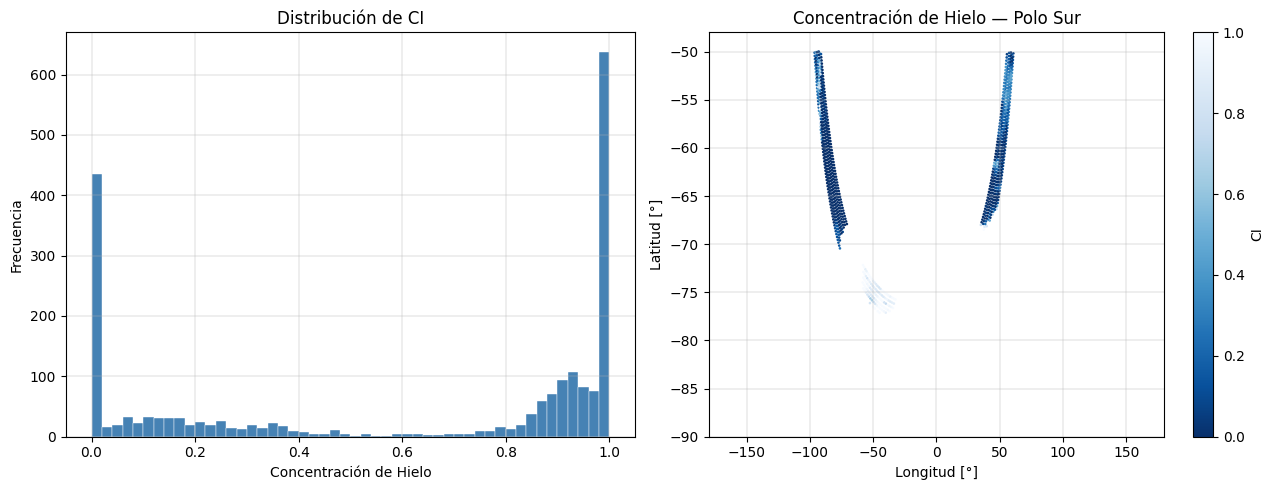

In [19]:
# Histograma de CI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.hist(ci_valid, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax1.set_xlabel('Concentración de Hielo')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de CI')
ax1.grid(True, linewidth=0.3)

# Mapa de CI
lat_ci = CI[0, :];  lon_ci = CI[1, :]
ci_map = CI[5, :]
mask = (lat_ci < -50) & (ci_map >= 0) & (ci_map <= 1)
sc = ax2.scatter(lon_ci[mask], lat_ci[mask], c=ci_map[mask],
                 s=3, cmap='Blues_r', vmin=0, vmax=1, marker='.')
ax2.set_xlim(-180, 180);  ax2.set_ylim(-90, -48)
ax2.set_xlabel('Longitud [°]');  ax2.set_ylabel('Latitud [°]')
ax2.set_title('Concentración de Hielo — Polo Sur')
ax2.grid(True, linewidth=0.3)
fig.colorbar(sc, ax=ax2, label='CI')
plt.tight_layout();  plt.show()


## 9. Procesamiento batch — todas las pasadas

`multi_passes_pro` automatiza la ejecución anterior sobre todos los
archivos L1B de un directorio. Internamente usa la misma cadena:
`load_l1b → apply_lat_filter → apply_land_filter → collocate_beams → compute_dtemp`.

Por cada archivo genera:
- `PG<nombre>.mat` con la variable `dtemp`
- `control_<nombre>.png` con el gráfico de verificación de ΔT


In [20]:
from multi_passes_pro import multi_passes_pro

# Paso 1: L1B (.h5) → dtemp (.mat)  — uno por pasada
multi_passes_pro(
    indir         = L1_DIR,
    oudir         = DPG_DIR,
    pattern       = 'EO_*.h5',
    prefix        = 'PG',
    mode          = 'delta_pg',
    landmask_file = LANDMASK,
    recursive     = True,
)



  Archivos encontrados: 99
  Entrada:  /home/adaip/Documentos/cursos/M5/M5-P4-Exc/data/L1
  Salida:   /home/adaip/Documentos/cursos/M5/M5-P4-Exc/data/Temp/DeltaP_G50S1v1
  Modo:     delta_pg

[1/99] EO_20130424_000704_CUSS_SACD_MWR_L1B_SCI_078_000_004.h5
  Leyendo: EO_20130424_000704_CUSS_SACD_MWR_L1B_SCI_078_000_004.h5
    Filtro lat:    [1916, 1917, 1817]
    Filtro tierra: [[820 825 860 897 893 911 927 924]
 [793 792 832 846 856 862 889 881]]
    Co-loc 36GHz:  [269 270 280 294 294 298 303 302]
    Válidos final: [260 245 266 272 274 280 274 287]
    dtemp shape:   (8, 5, 287)
    Guardado:      /home/adaip/Documentos/cursos/M5/M5-P4-Exc/data/Temp/DeltaP_G50S1v1/PGEO_20130424_000704_CUSS_SACD_MWR_L1B_SCI_078_000_004.mat
  Figura guardada: /home/adaip/Documentos/cursos/M5/M5-P4-Exc/data/Temp/DeltaP_G50S1v1/control_EO_20130424_000704_CUSS_SACD_MWR_L1B_SCI_078_000_004.png
  elapsed: 0.9 s

[2/99] EO_20130424_014452_CUSS_SACD_MWR_L1B_SCI_071_000_004.h5
  Leyendo: EO_20130424_014452_CUS

[0.9218078779995267,
 1.8872059589994024,
 3.000359459999345,
 4.042321154999627,
 5.0676879499997085,
 6.016444052999759,
 6.981352779999725,
 7.910785991999546,
 8.984717657999681,
 10.176727005999965,
 11.628378810999493,
 12.75618080699951,
 13.862582406999536,
 14.832325641999887,
 15.795712037000158,
 17.00768356699973,
 18.05524468800013,
 19.08765171699997,
 20.19418736499938,
 21.21809517499969,
 22.19553824200011,
 23.17530708599952,
 24.28256550900005,
 25.32979756899931,
 26.300026490000164,
 27.235902918999273,
 28.218648100999417,
 29.349270212999727,
 30.414426569999705,
 31.492735516999346,
 32.6266771519995,
 33.88694982200013,
 34.97485992199927,
 35.97554870499971,
 36.975607177999336,
 37.91615804999947,
 38.891544651000004,
 39.92809315299928,
 41.00842446699971,
 42.03668570699938,
 43.332420858999285,
 44.37434804999975,
 45.47345351799959,
 46.788624629999504,
 47.89194312899963,
 49.113760108999486,
 50.23429385899999,
 51.37328398599948,
 52.41097008499946,
 5

In [21]:
# Paso 2: dtemp (.mat) → CI (.mat)  — uno por pasada
multi_passes_pro(
    indir   = DPG_DIR,
    oudir   = CI_DIR,
    pattern = 'PG*.mat',
    prefix  = 'CI',
    mode    = 'ic',
)



  Archivos encontrados: 99
  Entrada:  /home/adaip/Documentos/cursos/M5/M5-P4-Exc/data/Temp/DeltaP_G50S1v1
  Salida:   /home/adaip/Documentos/cursos/M5/M5-P4-Exc/data/L2/CI_50S
  Modo:     ic

[1/99] PGEO_20130424_000704_CUSS_SACD_MWR_L1B_SCI_078_000_004.mat
  Saved CI (7, 2158) → /home/adaip/Documentos/cursos/M5/M5-P4-Exc/data/L2/CI_50S/CIPGEO_20130424_000704_CUSS_SACD_MWR_L1B_SCI_078_000_004.mat
  elapsed: 0.0 s

[2/99] PGEO_20130424_014452_CUSS_SACD_MWR_L1B_SCI_071_000_004.mat
  Saved CI (7, 2616) → /home/adaip/Documentos/cursos/M5/M5-P4-Exc/data/L2/CI_50S/CIPGEO_20130424_014452_CUSS_SACD_MWR_L1B_SCI_071_000_004.mat
  elapsed: 0.0 s

[3/99] PGEO_20130424_032240_CUSS_SACD_MWR_L1B_SCI_064_000_004.mat
  Saved CI (7, 3162) → /home/adaip/Documentos/cursos/M5/M5-P4-Exc/data/L2/CI_50S/CIPGEO_20130424_032240_CUSS_SACD_MWR_L1B_SCI_064_000_004.mat
  elapsed: 0.0 s

[4/99] PGEO_20130424_050028_CUSS_SACD_MWR_L1B_SCI_057_000_004.mat
  Saved CI (7, 3085) → /home/adaip/Documentos/cursos/M5/M5-P4-

[0.003225733999897784,
 0.004659729000195512,
 0.006872871000268788,
 0.008470486999613058,
 0.01122946800023783,
 0.012109936999877391,
 0.012861514999713108,
 0.0158467869996457,
 0.017871780999485054,
 0.021906885000134935,
 0.023080266999386367,
 0.024032297999838192,
 0.024930593999670236,
 0.02568328599954839,
 0.026601415999721212,
 0.027692147999914596,
 0.02859099199940829,
 0.029645876999893517,
 0.030510202000186837,
 0.03131292800026131,
 0.03201885399994353,
 0.03314497199971811,
 0.03420769999956974,
 0.03539565299979586,
 0.03626817500025936,
 0.03716060999977344,
 0.038017642999875534,
 0.03881743500005541,
 0.03966744499939523,
 0.040351400999497855,
 0.041054940999856626,
 0.04183646099954785,
 0.04262803300025553,
 0.04336229000000458,
 0.044219483000233595,
 0.045309148999876925,
 0.04648159999942436,
 0.04774529999940569,
 0.04884624499936763,
 0.04959890000009182,
 0.05032637899967085,
 0.0514010139995662,
 0.05205893199945422,
 0.05290590499953396,
 0.05401306499

## 10. Concatenación multipasada

Para generar productos globales se necesitan concatenar todas las pasadas.
`concat_multipass` detecta automáticamente el nombre de la variable en
el `.mat` y la concatena a lo largo del eje de registros:

| Archivo de salida | Variable | Shape individual | Eje | Uso |
|---|---|---|---|---|
| `MultiPG.mat` | `adtemp` | `(8, 5, N)` | 2 | input de `ice_scatter` |
| `MultiCI.mat` | `aCI` | `(7, M)` | 1 | input de `grafic_ci` |


In [22]:
from concat_multipass import concat_multipass

# Concatenar dtemp de todas las pasadas → MultiPG.mat
adtemp = concat_multipass(
    path    = DPG_DIR,
    pattern = 'PGEO_*.mat',
    oufile  = os.path.join(DPG_DIR, 'MultiPG.mat'),
    axis    = 2,
)
print(f'MultiPG.mat  →  adtemp shape: {adtemp.shape}')


[1/99]  PGEO_20130424_000704_CUSS_SACD_MWR_L1B_SCI_078_000_004.mat  shape=(8, 5, 287)  var="dtemp"  elapsed=0.0s
[2/99]  PGEO_20130424_014452_CUSS_SACD_MWR_L1B_SCI_071_000_004.mat  shape=(8, 5, 647)  elapsed=0.0s
[3/99]  PGEO_20130424_032240_CUSS_SACD_MWR_L1B_SCI_064_000_004.mat  shape=(8, 5, 1077)  elapsed=0.0s
[4/99]  PGEO_20130424_050028_CUSS_SACD_MWR_L1B_SCI_057_000_004.mat  shape=(8, 5, 1485)  elapsed=0.0s
[5/99]  PGEO_20130424_063817_CUSS_SACD_MWR_L1B_SCI_050_000_004.mat  shape=(8, 5, 1894)  elapsed=0.0s
[6/99]  PGEO_20130424_081605_CUSS_SACD_MWR_L1B_SCI_043_000_004.mat  shape=(8, 5, 2210)  elapsed=0.0s
[7/99]  PGEO_20130424_095353_CUSS_SACD_MWR_L1B_SCI_036_000_004.mat  shape=(8, 5, 2517)  elapsed=0.0s
[8/99]  PGEO_20130424_113141_CUSS_SACD_MWR_L1B_SCI_029_000_004.mat  shape=(8, 5, 2812)  elapsed=0.0s
[9/99]  PGEO_20130424_130930_CUSS_SACD_MWR_L1B_SCI_022_000_004.mat  shape=(8, 5, 3102)  elapsed=0.0s
[10/99]  PGEO_20130424_144718_CUSS_SACD_MWR_L1B_SCI_015_000_004.mat  shape=(8, 5

In [23]:
# Concatenar CI de todas las pasadas → MultiCI.mat
aCI = concat_multipass(
    path    = CI_DIR,
    pattern = 'CIPGEO_*.mat',
    oufile  = os.path.join(CI_DIR, 'MultiCI.mat'),
    axis    = 1,
)
print(f'MultiCI.mat  →  aCI shape: {aCI.shape}')


[1/99]  CIPGEO_20130424_000704_CUSS_SACD_MWR_L1B_SCI_078_000_004.mat  shape=(7, 2158)  var="CI"  elapsed=0.0s
[2/99]  CIPGEO_20130424_014452_CUSS_SACD_MWR_L1B_SCI_071_000_004.mat  shape=(7, 4774)  elapsed=0.0s
[3/99]  CIPGEO_20130424_032240_CUSS_SACD_MWR_L1B_SCI_064_000_004.mat  shape=(7, 7936)  elapsed=0.0s
[4/99]  CIPGEO_20130424_050028_CUSS_SACD_MWR_L1B_SCI_057_000_004.mat  shape=(7, 11021)  elapsed=0.0s
[5/99]  CIPGEO_20130424_063817_CUSS_SACD_MWR_L1B_SCI_050_000_004.mat  shape=(7, 14026)  elapsed=0.0s
[6/99]  CIPGEO_20130424_081605_CUSS_SACD_MWR_L1B_SCI_043_000_004.mat  shape=(7, 16453)  elapsed=0.0s
[7/99]  CIPGEO_20130424_095353_CUSS_SACD_MWR_L1B_SCI_036_000_004.mat  shape=(7, 18498)  elapsed=0.0s
[8/99]  CIPGEO_20130424_113141_CUSS_SACD_MWR_L1B_SCI_029_000_004.mat  shape=(7, 20673)  elapsed=0.0s
[9/99]  CIPGEO_20130424_130930_CUSS_SACD_MWR_L1B_SCI_022_000_004.mat  shape=(7, 22779)  elapsed=0.0s
[10/99]  CIPGEO_20130424_144718_CUSS_SACD_MWR_L1B_SCI_015_000_004.mat  shape=(7, 251

## 11. Scatter plots de densidad PR-GR por haz

`ice_scatter` toma el `MultiPG.mat` y construye una matriz de densidad
en el espacio ΔTp vs ΔTg para cada combinación de haz (1-8) y tipo
de pasada (ascendente/descendente).

Estas densidades son útiles para:
- Verificar la calidad de los datos
- Identificar y ajustar tie points
- Comparar el comportamiento entre haces


In [24]:
from ice_scatter import ice_scatter

SCATTER_DIR = os.path.join(DPG_DIR, 'Scatter')
MULTIPG     = os.path.join(DPG_DIR, 'MultiPG.mat')

if os.path.isfile(MULTIPG):
    ice_scatter(
        path   = SCATTER_DIR,
        infile = MULTIPG,
        prefix = 'ScatterPG_',
    )
    print(f'Scatter plots guardados en: {SCATTER_DIR}')
else:
    print('MultiPG.mat no encontrado — ejecutar paso 10 primero')


  B1D  n=25215  max_density=348
  B1A  n=2614  max_density=30
  B2D  n=23971  max_density=296
  B2A  n=2512  max_density=34
  B3D  n=25601  max_density=369
  B3A  n=2602  max_density=41
  B4D  n=25126  max_density=326
  B4A  n=2608  max_density=34
  B5D  n=25699  max_density=367
  B5A  n=2593  max_density=39
  B6D  n=26683  max_density=325
  B6A  n=2758  max_density=34
  B7D  n=25685  max_density=419
  B7A  n=2574  max_density=38
  B8D  n=27618  max_density=306
  B8A  n=2809  max_density=36
Scatter plots guardados en: /home/adaip/Documentos/cursos/M5/M5-P4-Exc/data/Temp/DeltaP_G50S1v1/Scatter


## 12. Mapas de Concentración de Hielo

`grafic_ci` genera 6 mapas PNG con distintas proyecciones y filtros:

| Archivo | Proyección | Región |
|---|---|---|
| `IC_all_TM.png` | Mercator Transversa | Global |
| `IC_wB2_TM.png` | Mercator Transversa | Global, sin haz 2 |
| `IC_all_NP.png` | Estereográfica | Polo Norte (lat > 50°) |
| `IC_wB2_NP.png` | Estereográfica | Polo Norte, sin haz 2 |
| `IC_all_SP.png` | Estereográfica | Polo Sur (lat < −50°) |
| `IC_wB2_SP.png` | Estereográfica | Polo Sur, sin haz 2 |

> El **haz 2** puede presentar contaminación por interferencia RFI
> y se excluye en las variantes `wB2`.


In [26]:
from grafic_ci import plot_ci

MULTICI = os.path.join(CI_DIR, 'MultiCI.mat')

if os.path.isfile(MULTICI):
    plot_ci(
        infile    = MULTICI,
        outpath   = CI_DIR,
        multipass = True,
    )
    print('Mapas guardados en:', CI_DIR)
else:
    print('MultiCI.mat no encontrado — ejecutar pasos 9 y 10 primero')


  Saved: IC_all_TM.png
  Saved: IC_wB2_TM.png
  Saved: IC_all_NP.png
  Saved: IC_wB2_NP.png
  Saved: IC_all_SP.png
  Saved: IC_wB2_SP.png
Mapas guardados en: /home/adaip/Documentos/cursos/M5/M5-P4-Exc/data/L2/CI_50S


In [ ]:
# Mostramos los mapas generados directamente en el notebook
from IPython.display import Image, display
import glob

mapas = sorted(glob.glob(os.path.join(CI_DIR, 'IC_*.png')))
if mapas:
    for mapa in mapas:
        print(os.path.basename(mapa))
        display(Image(mapa, width=800))
else:
    print('No se encontraron mapas — ejecutar el paso anterior primero')


## Resumen del pipeline

```
Archivo L1B (.h5)
    │
    ├── load_l1b()              → data[rx][bkey] = {Lat, Lon, Tb}
    ├── apply_lat_filter()      → rawlat  (8 haces, |lat|>49°)
    ├── apply_land_filter()     → rawland (sin tierra)
    ├── collocate_beams()       → rawloc  (36 GHz ↔ 23 GHz co-localizados)
    └── compute_dtemp()         → dtemp (8, 5, N)  →  PG*.mat
                                                         │
                              process_ic(dtemp)   →  CI*.mat

[para todas las pasadas]
    multi_passes_pro  mode=1   →  PG*.mat  (uno por pasada)
    multi_passes_pro  mode=2   →  CI*.mat  (uno por pasada)

[concatenación]
    concat_multipass  axis=2   →  MultiPG.mat  (adtemp)
    concat_multipass  axis=1   →  MultiCI.mat  (aCI)

[productos finales]
    ice_scatter(MultiPG)       →  ScatterPG_B*{A,D}.{mat,png}
    grafic_ci(MultiCI)         →  IC_*.png
```

---
*Proyecto SACD — Área de Teledetección · ADAIP · CONAE*
